# Week 6 Capstone: Customer Churn Prediction and Segmentation
**End-to-end Data Science with Python**

This project integrates data acquisition, cleaning, feature engineering, EDA, K-Means segmentation, supervised learning, deep learning, evaluation, and business interpretation.

**Dataset:** IBM Telco Customer Churn  
**Source:** https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Download the CSV and place it beside this notebook. Common filename: `WA_Fn-UseC_-Telco-Customer-Churn.csv`. Run all cells to generate actual metrics and charts; do not invent results.

## 1. Setup

In [1]:
# If needed, uncomment:
# %pip install pandas numpy matplotlib seaborn scikit-learn tensorflow joblib

from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, silhouette_score)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
OUT = Path("outputs"); FIG = Path("visualizations")
OUT.mkdir(exist_ok=True); FIG.mkdir(exist_ok=True)
sns.set_theme()

## 2. Acquire and inspect data

In [2]:
DATA_PATH = Path("WA_Fn-UseC_-Telco-Customer-Churn.csv")
if not DATA_PATH.exists():
    for candidate in [Path("Telco-Customer-Churn.csv"),
                      Path("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"),
                      Path("/content/Telco-Customer-Churn.csv")]:
        if candidate.exists():
            DATA_PATH = candidate
            break
if not DATA_PATH.exists():
    raise FileNotFoundError("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)

Shape: (7043, 21)


In [4]:
display(df.head())
print("\nDataFrame Info:")
display(df.info())
print("\nDataFrame Description:")    
display(df.describe(include="all").T)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   st

None


DataFrame Description:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
audit = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean()*100).round(2)
}).sort_values("missing_count", ascending=False)
display(audit)
print("Duplicate rows:", df.duplicated().sum())
display(df["Churn"].value_counts(dropna=False))

,missing_count,missing_percent
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Duplicate rows: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## 3. Clean data and engineer features

In [6]:
if "TotalCharges" in df:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
duplicates_removed = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
df["Churn"] = df["Churn"].astype("string").str.strip()
df = df[df["Churn"].isin(["Yes", "No"])].copy()
df["ChurnBinary"] = df["Churn"].map({"No": 0, "Yes": 1}).astype(int)

df["EstimatedCustomerValue"] = df["tenure"] * df["MonthlyCharges"]
df["TenureGroup"] = pd.cut(
    df["tenure"], [-1, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"]
)
service_cols = [c for c in ["OnlineSecurity","OnlineBackup","DeviceProtection",
    "TechSupport","StreamingTV","StreamingMovies"] if c in df.columns]
df["HasMultipleServices"] = (df[service_cols].eq("Yes").sum(axis=1).ge(2).astype(int)
                             if service_cols else 0)
print("\nDuplicate rows removed:", duplicates_removed)
print("\nCleaned shape:", df.shape)
print("\nChurn rate (%):", round(df["ChurnBinary"].mean()*100, 2))
display(df[["tenure","MonthlyCharges","EstimatedCustomerValue","TenureGroup"]].head())


Duplicate rows removed: 0

Cleaned shape: (7043, 25)

Churn rate (%): 26.54


,tenure,MonthlyCharges,EstimatedCustomerValue,TenureGroup
0,1,29.85,29.85,0-12 Months
1,34,56.95,1936.30,25-48 Months
2,2,53.85,107.70,0-12 Months
3,45,42.30,1903.50,25-48 Months
4,2,70.70,141.40,0-12 Months


## 4. Exploratory Data Analysis

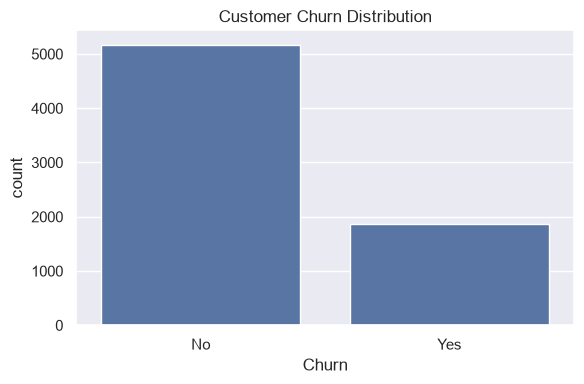

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn", order=["No","Yes"])
plt.title("Customer Churn Distribution"); plt.tight_layout()
plt.savefig(FIG/"01_churn_distribution.png", dpi=160); plt.show()



In [8]:
contract_rates = df.groupby("Contract", observed=False)["ChurnBinary"].mean().mul(100).sort_values(ascending=False)
display(contract_rates.rename("churn_rate_percent").to_frame())

,churn_rate_percent
Contract,
Month-to-month,42.709677
One year,11.269518
Two year,2.831858


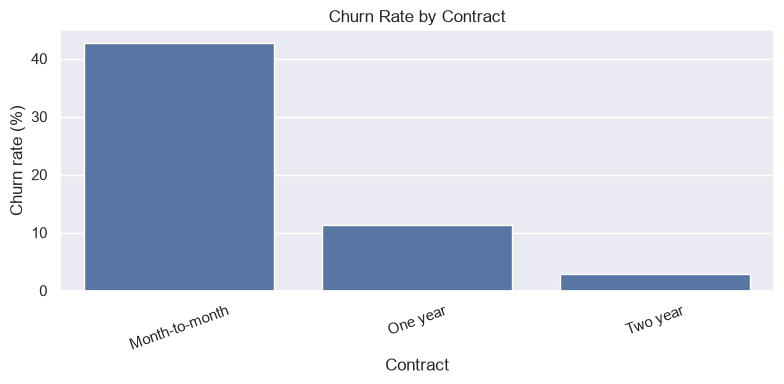

In [9]:
plt.figure(figsize=(8,4))
sns.barplot(x=contract_rates.index, y=contract_rates.values)
plt.title("Churn Rate by Contract"); plt.ylabel("Churn rate (%)")
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(FIG/"02_churn_by_contract.png", dpi=160); plt.show()

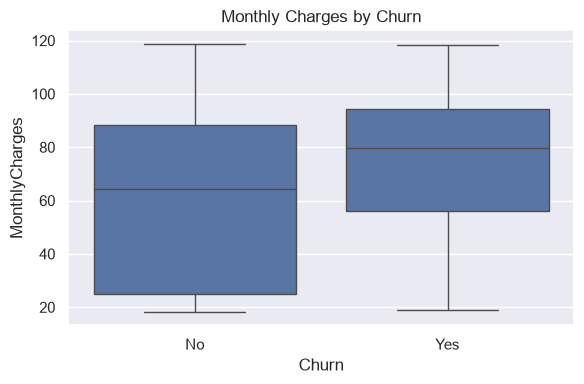

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", order=["No","Yes"])
plt.title("Monthly Charges by Churn"); plt.tight_layout()
plt.savefig(FIG/"03_monthly_charges_by_churn.png", dpi=160); plt.show()

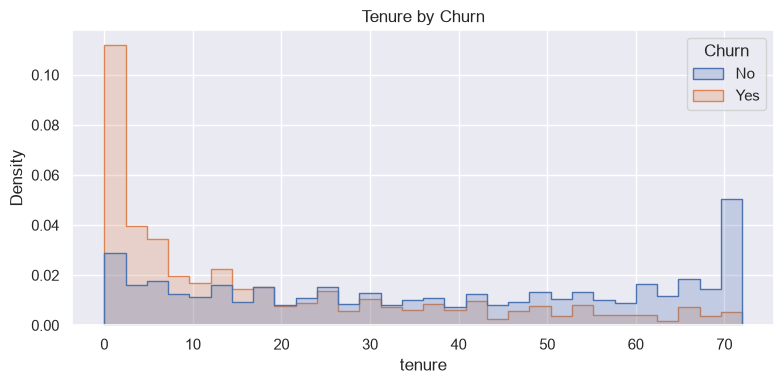

In [11]:
plt.figure(figsize=(8,4))
sns.histplot(data=df, x="tenure", hue="Churn", bins=30,
             element="step", stat="density", common_norm=False)
plt.title("Tenure by Churn"); plt.tight_layout()
plt.savefig(FIG/"04_tenure_by_churn.png", dpi=160); plt.show()

In [12]:
tenure_rates = df.groupby("TenureGroup", observed=False)["ChurnBinary"].mean().mul(100)
display(tenure_rates.rename("churn_rate_percent").to_frame())

,churn_rate_percent
TenureGroup,
0-12 Months,47.438243
13-24 Months,28.710938
25-48 Months,20.388959
49-72 Months,9.513176


## 5. Unsupervised learning: K-Means

In [13]:
cluster_features = ["tenure", "MonthlyCharges", "TotalCharges"]
cluster_data = df[cluster_features].dropna()
cluster_scaler = StandardScaler()
Xc = cluster_scaler.fit_transform(cluster_data)
cluster_rows = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(Xc)
    cluster_rows.append({"k": k, "inertia": km.inertia_,
                         "silhouette": silhouette_score(Xc, labels)})
cluster_scores = pd.DataFrame(cluster_rows)
display(cluster_scores)
cluster_scores.to_csv(OUT/"clustering_scores.csv", index=False)

,k,inertia,silhouette
0,2,9700.829985,0.479524
1,3,6176.723824,0.451513
2,4,4144.587713,0.472085
3,5,3108.410479,0.443269
4,6,2559.841473,0.437604
5,7,2177.749626,0.431087
6,8,1861.116632,0.427332


PermissionError: [Errno 13] Permission denied: 'outputs\\clustering_scores.csv'

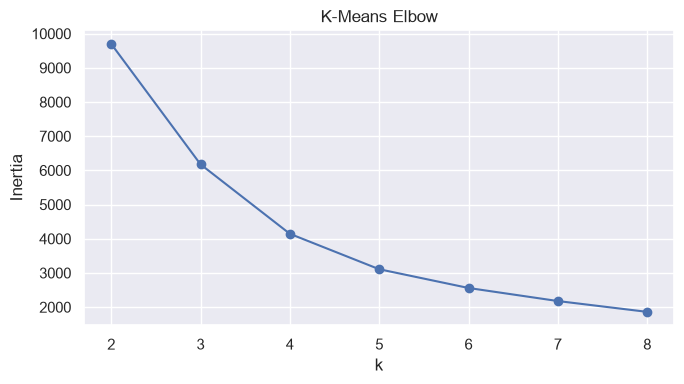

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(cluster_scores.k, cluster_scores.inertia, marker="o")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.title("K-Means Elbow")
plt.tight_layout(); plt.savefig(FIG/"05_kmeans_elbow.png", dpi=160); plt.show()

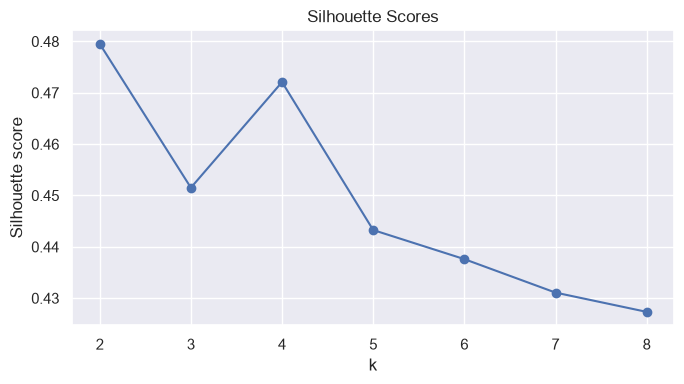

In [ ]:
plt.figure(figsize=(7,4))
plt.plot(cluster_scores.k, cluster_scores.silhouette, marker="o")
plt.xlabel("k"); plt.ylabel("Silhouette score"); plt.title("Silhouette Scores")
plt.tight_layout(); plt.savefig(FIG/"06_kmeans_silhouette.png", dpi=160); plt.show()

In [ ]:
# Review elbow/silhouette charts and change this value if appropriate.
SELECTED_K = 4
kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
clustered = df.loc[cluster_data.index].copy()
clustered["Cluster"] = kmeans.fit_predict(Xc)
profile = clustered.groupby("Cluster").agg(
    customer_count=("Cluster","size"),
    average_tenure=("tenure","mean"),
    average_monthly_charges=("MonthlyCharges","mean"),
    average_total_charges=("TotalCharges","mean"),
    churn_rate_percent=("ChurnBinary", lambda s: s.mean()*100)
).round(2)
display(profile)
profile.to_csv(OUT/"cluster_profile.csv")



,customer_count,average_tenure,average_monthly_charges,average_total_charges,churn_rate_percent
Cluster,,,,,
0,1696,10.28,31.78,303.82,24.76
1,1904,59.53,93.31,5548.65,15.39
2,1159,53.59,34.92,1836.58,5.00
3,2273,15.45,80.79,1252.82,48.31


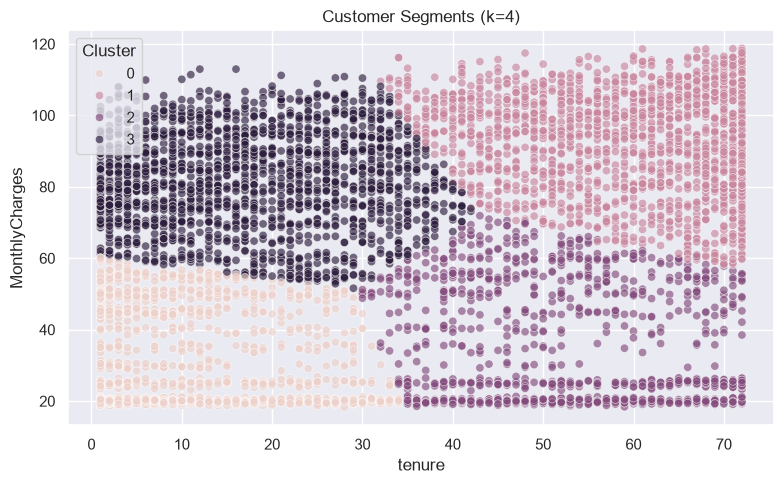

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=clustered, x="tenure", y="MonthlyCharges", hue="Cluster", alpha=.65)
plt.title(f"Customer Segments (k={SELECTED_K})"); plt.tight_layout()
plt.savefig(FIG/"07_customer_segments.png", dpi=160); plt.show()

## 6. Supervised learning: Logistic Regression and Random Forest

In [ ]:
y = df["ChurnBinary"]
X = df.drop(columns=["Churn","ChurnBinary","customerID",
                     "EstimatedCustomerValue","TenureGroup"], errors="ignore")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE
)


In [ ]:
num_cols = X_train.select_dtypes(include=["number","bool"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number","bool"]).columns.tolist()
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
])


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=250, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2)
}
fitted, predictions, rows = {}, {}, []
for name, estimator in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:,1]
    fitted[name] = pipe; predictions[name] = (pred, prob)
    rows.append({"model": name, "accuracy": accuracy_score(y_test,pred),
        "precision": precision_score(y_test,pred,zero_division=0),
        "recall": recall_score(y_test,pred,zero_division=0),
        "f1": f1_score(y_test,pred,zero_division=0),
        "roc_auc": roc_auc_score(y_test,prob)})
results = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
display(results.round(4))
results.to_csv(OUT/"supervised_model_comparison.csv", index=False)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.7424,0.5095,0.7914,0.6199,0.842
1,Random Forest,0.7573,0.5320,0.7112,0.6087,0.836


## 7. Cross-validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, estimator in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", estimator)])
    scores = cross_validate(pipe, X_train, y_train, cv=cv,
        scoring=["accuracy","precision","recall","f1","roc_auc"], n_jobs=-1)
    row = {"model": name}
    for metric in ["accuracy","precision","recall","f1","roc_auc"]:
        row[metric+"_mean"] = float(np.mean(scores["test_"+metric]))
        row[metric+"_std"] = float(np.std(scores["test_"+metric], ddof=1))
    cv_rows.append(row)
cv_results = pd.DataFrame(cv_rows)
display(cv_results.round(4))
cv_results.to_csv(OUT/"cross_validation_results.csv", index=False)

,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.7480,0.0150,0.5163,0.0187,0.7973,0.0394,0.6266,0.0233,0.8461,0.0138
1,Random Forest,0.7716,0.0109,0.5531,0.0160,0.7251,0.0279,0.6274,0.0190,0.8377,0.0101


## 8. Evaluation, confusion matrix, ROC curves, and errors

In [ ]:
best_name = results.iloc[0]["model"]
best_pipe = fitted[best_name]
best_pred, best_prob = predictions[best_name]
print("Selected for error analysis:", best_name)
print(classification_report(y_test, best_pred,
      target_names=["Retained","Churned"], zero_division=0))


Selected for error analysis: Logistic Regression
              precision    recall  f1-score   support

    Retained       0.91      0.72      0.81      1035
     Churned       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



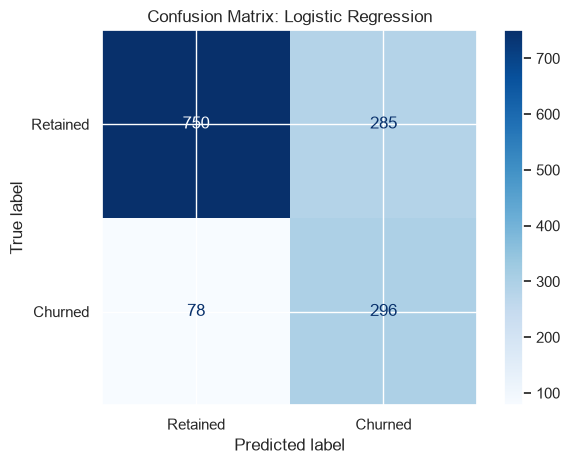

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, best_pred,
    display_labels=["Retained","Churned"], cmap="Blues")
plt.title("Confusion Matrix: "+best_name); plt.tight_layout()
plt.savefig(FIG/"08_confusion_matrix.png", dpi=160); plt.show()



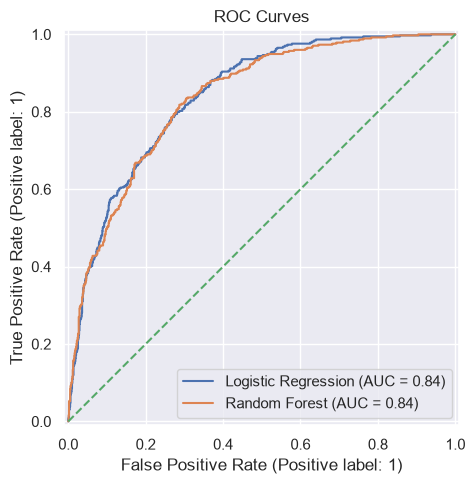

In [ ]:
fig, ax = plt.subplots(figsize=(7,5))
for name, (pred, prob) in predictions.items():
    RocCurveDisplay.from_predictions(y_test, prob, name=name, ax=ax)
ax.plot([0,1],[0,1], "--")
plt.title("ROC Curves"); plt.tight_layout()
plt.savefig(FIG/"09_roc_curves.png", dpi=160); plt.show()

In [ ]:
errors = X_test.copy()
errors["actual_churn"] = y_test
errors["predicted_churn"] = best_pred
errors["predicted_probability"] = best_prob
errors["error_type"] = np.select([
    (errors.actual_churn==1)&(errors.predicted_churn==0),
    (errors.actual_churn==0)&(errors.predicted_churn==1)],
    ["False Negative","False Positive"], default="Correct")
errors.to_csv(OUT/"test_error_analysis.csv", index=False)
display(errors[errors.error_type!="Correct"].head(10))

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,HasMultipleServices,actual_churn,predicted_churn,predicted_probability,error_type
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,...,Month-to-month,Yes,Credit card (automatic),100.15,908.55,1,0,1,0.849043,False Positive
4460,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,...,Month-to-month,No,Electronic check,78.20,1468.75,1,0,1,0.631384,False Positive
5748,Female,0,No,No,21,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Credit card (automatic),99.85,1992.55,1,0,1,0.802890,False Positive
3568,Female,0,No,No,21,Yes,No,Fiber optic,No,Yes,...,Month-to-month,Yes,Bank transfer (automatic),99.15,1956.40,1,0,1,0.706063,False Positive
2079,Male,0,Yes,Yes,70,Yes,Yes,Fiber optic,Yes,Yes,...,Month-to-month,Yes,Electronic check,106.05,7554.05,1,0,1,0.519497,False Positive
2136,Male,0,No,Yes,15,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,91.00,1430.05,1,0,1,0.805577,False Positive
1242,Female,0,Yes,No,21,No,No phone service,DSL,Yes,No,...,Month-to-month,No,Electronic check,28.50,629.35,0,0,1,0.531945,False Positive
1838,Male,1,No,No,54,Yes,Yes,Fiber optic,No,Yes,...,Month-to-month,Yes,Electronic check,90.05,4931.80,1,0,1,0.679448,False Positive
6979,Male,0,No,Yes,1,No,No phone service,DSL,No,No,...,Month-to-month,No,Mailed check,24.20,24.20,0,0,1,0.666537,False Positive
2488,Male,0,No,No,31,Yes,No,DSL,No,No,...,Month-to-month,Yes,Electronic check,55.25,1715.65,1,1,0,0.375584,False Negative


## 9. Feature importance

In [ ]:
n = min(1000, len(X_test))
X_imp = X_test.sample(n=n, random_state=RANDOM_STATE)
y_imp = y_test.loc[X_imp.index]
perm = permutation_importance(best_pipe, X_imp, y_imp, scoring="roc_auc",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
importance = pd.DataFrame({"feature": X.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std}).sort_values("importance_mean", ascending=False)
display(importance.head(15).round(4))
importance.to_csv(OUT/"permutation_feature_importance.csv", index=False)
top = importance.head(15).sort_values("importance_mean")

,feature,importance_mean,importance_std
4,tenure,0.1408,0.0063
7,InternetService,0.0467,0.0100
14,Contract,0.0413,0.0049
17,MonthlyCharges,0.0321,0.0028
18,TotalCharges,0.0115,0.0026
12,StreamingTV,0.0094,0.0030
13,StreamingMovies,0.0083,0.0029
6,MultipleLines,0.0038,0.0019
19,HasMultipleServices,0.0036,0.0011
8,OnlineSecurity,0.0034,0.0022


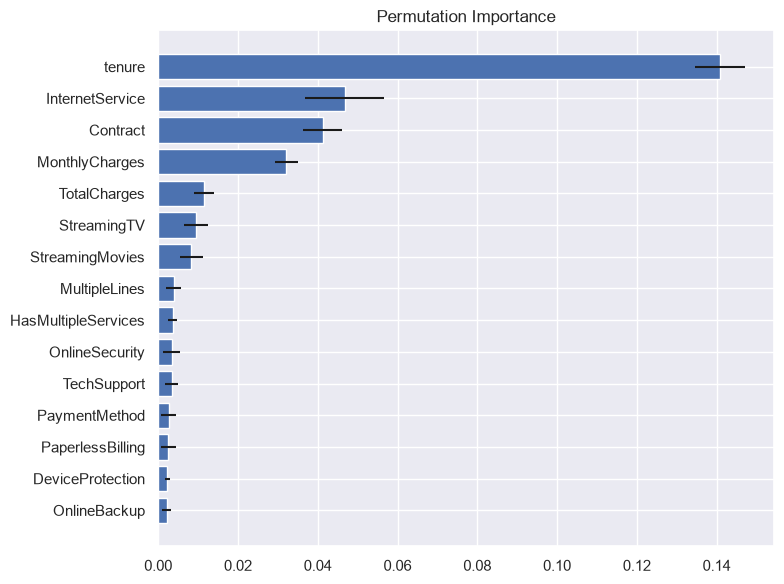

In [ ]:
plt.figure(figsize=(8,6))
plt.barh(top.feature, top.importance_mean, xerr=top.importance_std)
plt.title("Permutation Importance"); plt.tight_layout()
plt.savefig(FIG/"10_feature_importance.png", dpi=160); plt.show()

## 10. Deep learning: MLP

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(RANDOM_STATE)

# Dense one-hot matrix is convenient for a modest-sized tabular dataset.
nn_preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_cols)
])
Xtr = nn_preprocessor.fit_transform(X_train).astype("float32")
Xte = nn_preprocessor.transform(X_test).astype("float32")
ytr = y_train.to_numpy().astype("float32")
yte = y_test.to_numpy().astype("float32")
X_fit, X_val, y_fit, y_val = train_test_split(
    Xtr, ytr, test_size=.15, stratify=ytr, random_state=RANDOM_STATE
)

mlp = keras.Sequential([
    layers.Input(shape=(X_fit.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(.30),
    layers.Dense(64, activation="relu"),
    layers.Dropout(.20),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
mlp.compile(optimizer=keras.optimizers.Adam(learning_rate=.001),
    loss="binary_crossentropy",
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy"), keras.metrics.AUC(name="auc")])
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(str(OUT/"best_churn_mlp.keras"),
                                    monitor="val_loss", save_best_only=True)
]
history = mlp.fit(X_fit, y_fit, validation_data=(X_val,y_val),
    epochs=40, batch_size=64, callbacks=callbacks, verbose=1)


Epoch 1/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7057 - auc: 0.7012 - loss: 0.5323 - val_accuracy: 0.8156 - val_auc: 0.8434 - val_loss: 0.4277
Epoch 2/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7945 - auc: 0.8308 - loss: 0.4339 - val_accuracy: 0.8144 - val_auc: 0.8469 - val_loss: 0.4169
Epoch 3/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - auc: 0.8340 - loss: 0.4292 - val_accuracy: 0.8191 - val_auc: 0.8466 - val_loss: 0.4162
Epoch 4/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7978 - auc: 0.8393 - loss: 0.4237 - val_accuracy: 0.8191 - val_auc: 0.8465 - val_loss: 0.4190
Epoch 5/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8018 - auc: 0.8429 - loss: 0.4207 - val_accuracy: 0.8180 - val_auc: 0.8456 - val_loss: 0.4171
Epoch 6/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8016 - auc: 0.8456 - loss: 0.4173 - val_accuracy: 0.8180 - val_auc: 0.8455 - val_loss: 0.4178
Epoch 7/40
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - 

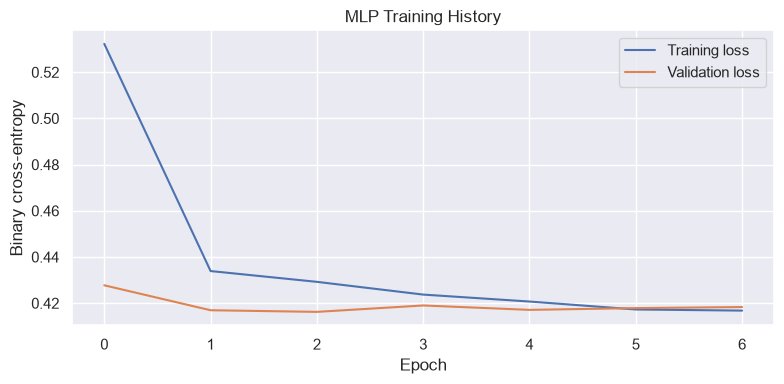

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Binary cross-entropy")
plt.title("MLP Training History"); plt.legend(); plt.tight_layout()
plt.savefig(FIG/"11_mlp_training_history.png", dpi=160); plt.show()

In [ ]:
nn_prob = mlp.predict(Xte, verbose=0).ravel()
nn_pred = (nn_prob >= .5).astype(int)
nn_result = {"model":"Neural Network (MLP)",
    "accuracy":accuracy_score(yte,nn_pred),
    "precision":precision_score(yte,nn_pred,zero_division=0),
    "recall":recall_score(yte,nn_pred,zero_division=0),
    "f1":f1_score(yte,nn_pred,zero_division=0),
    "roc_auc":roc_auc_score(yte,nn_prob)}
all_results = pd.concat([results, pd.DataFrame([nn_result])], ignore_index=True)
display(all_results.round(4))
all_results.to_csv(OUT/"all_model_comparison.csv", index=False)
mlp.save(OUT/"final_churn_mlp.keras")
joblib.dump(best_pipe, OUT/"best_sklearn_pipeline.joblib")

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.7424,0.5095,0.7914,0.6199,0.842
1,Random Forest,0.7573,0.5320,0.7112,0.6087,0.836
2,Neural Network (MLP),0.7970,0.6384,0.5428,0.5867,0.842


['outputs\\best_sklearn_pipeline.joblib']